In [1]:
import pandas as pd
import plotly.express as px
import seaborn as sns
from matplotlib import pyplot as plt, ticker as mtick
import torch
import os

In [2]:
os.chdir(r'C:\SML_Projects\SML_gym_fatPercentage_predict_project\DL')

In [3]:
df_path = r'C:\SML_Projects\SML_gym_fatPercentage_predict_project\data\DL\processed'

In [4]:
X_test = pd.read_csv(f'{df_path}/X_test.csv')
X_test = torch.tensor(X_test.values, dtype=torch.float32)

X_train = pd.read_csv(f'{df_path}/X_train.csv')
X_train = torch.tensor(X_train.values, dtype=torch.float32)

y_test = pd.read_csv(f'{df_path}/y_test.csv')
y_test = torch.tensor(y_test.values, dtype=torch.float32)

In [5]:
from src.model import StructuredNN

model = torch.load(r'C:\SML_Projects\SML_gym_fatPercentage_predict_project\model\structured_nn.pth')
model = StructuredNN(input_dim=X_train.shape[1])

In [6]:
model.eval()
with torch.no_grad():
    preds = model(X_test)
    y_pred = preds.numpy().flatten()

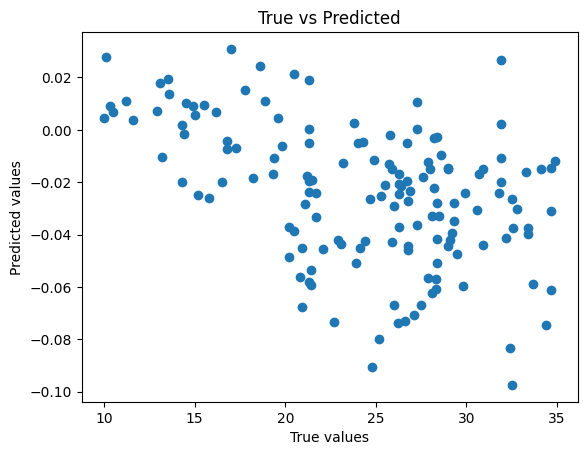

In [7]:
plt.scatter(y_test, y_pred)
plt.xlabel("True values")
plt.ylabel("Predicted values")
plt.title("True vs Predicted")
plt.show()

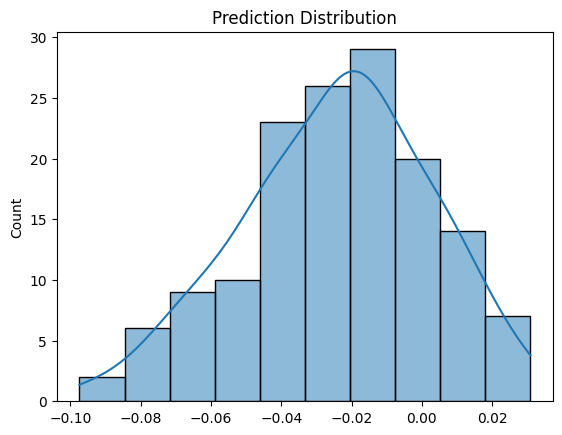

In [8]:
sns.histplot(y_pred, kde=True)
plt.title("Prediction Distribution")
plt.show()

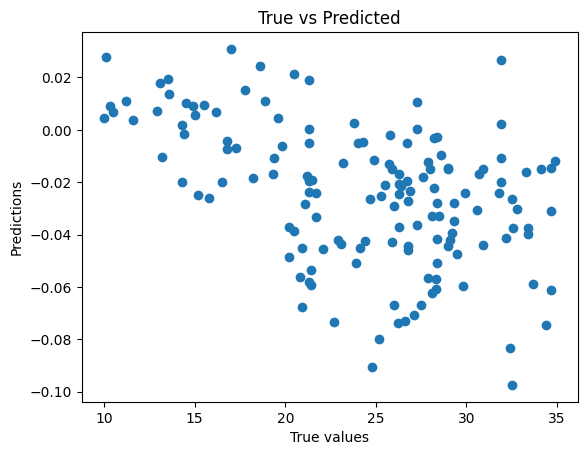

In [9]:
plt.scatter(y_test, y_pred)
plt.xlabel("True values")
plt.ylabel("Predictions")
plt.title("True vs Predicted")
plt.show()

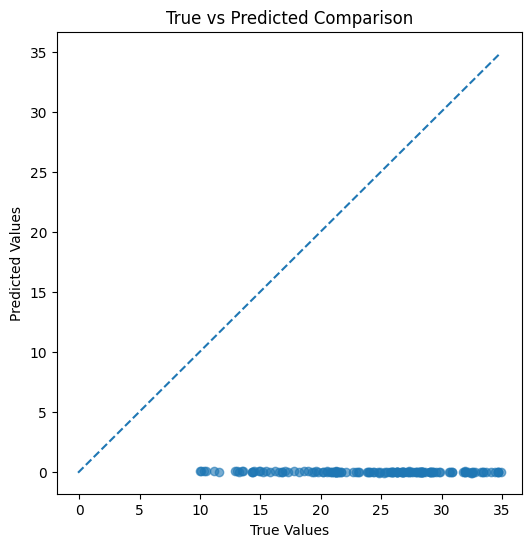

In [10]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.6)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle='--')
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title("True vs Predicted Comparison")
plt.show()

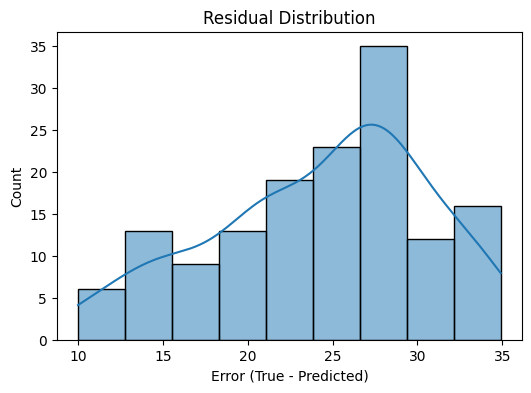

In [11]:
residuals = y_test.numpy().flatten() - y_pred

plt.figure(figsize=(6,4))
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.xlabel("Error (True - Predicted)")
plt.show()

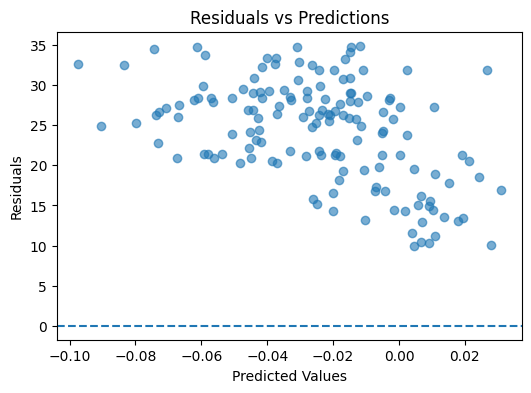

In [12]:
plt.figure(figsize=(6,4))
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(0, linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predictions")
plt.show()

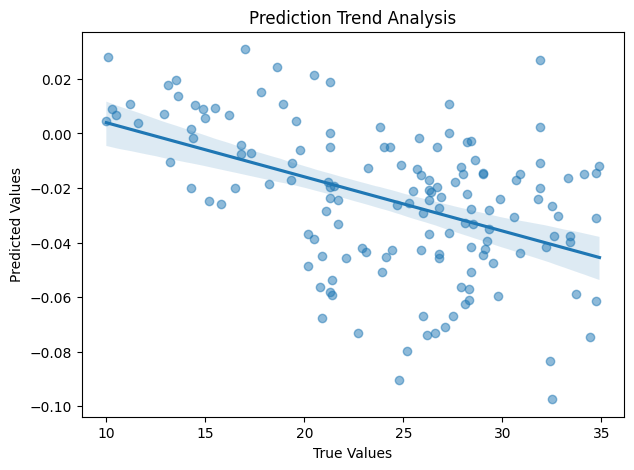

In [13]:
plt.figure(figsize=(7,5))
sns.regplot(x=y_test.numpy().flatten(), y=y_pred, scatter_kws={"alpha":0.5})
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title("Prediction Trend Analysis")
plt.show()

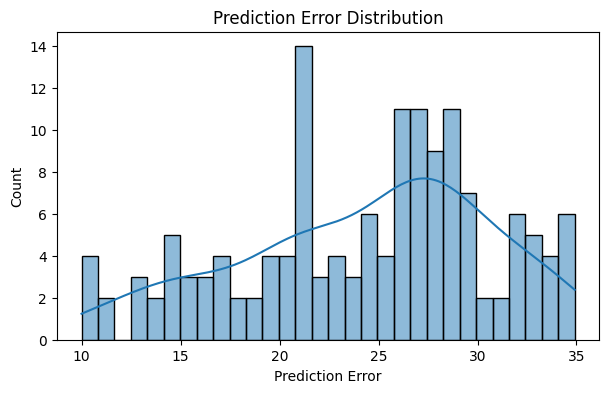

In [14]:
errors = y_test.numpy().flatten() - y_pred

plt.figure(figsize=(7,4))
sns.histplot(errors, bins=30, kde=True)
plt.xlabel("Prediction Error")
plt.title("Prediction Error Distribution")
plt.show()

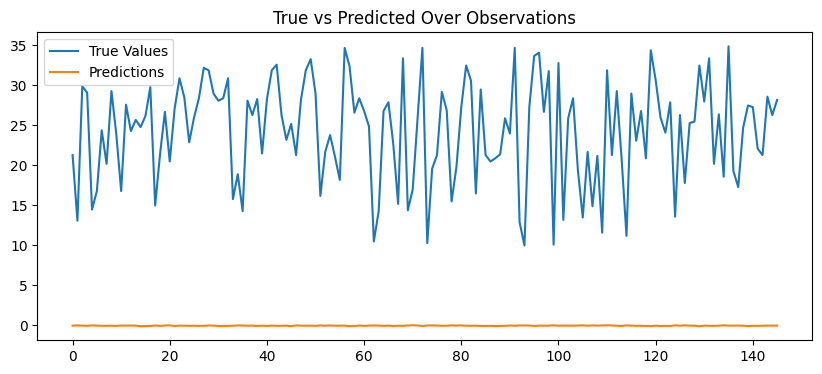

In [15]:
plt.figure(figsize=(10,4))
plt.plot(y_test.numpy().flatten(), label="True Values")
plt.plot(y_pred, label="Predictions")
plt.legend()
plt.title("True vs Predicted Over Observations")
plt.show()

In [16]:
px.scatter(
    x=y_test.numpy().flatten(),
    y=y_pred,
    labels={"x":"True Values", "y":"Predicted Values"},
    title="Interactive True vs Predicted"
)